# Wavelength-solution & barycentric-correction inspection

**Trigger**: the De Regt+2024-style CCF species validation (`Reminisce/paper_figures/fig_ccf_all.png`,
`fig_ccf_key.png`, retrieval job **3062330**) shows tentative-but-offset Na/Ca peaks and a
strong HF offset:

| species | global peak SNR | peak RV lag |
|---|---|---|
| Na | 3.94 | **-337.0 km/s** |
| Ca | 2.77 | **+539.0 km/s** |
| HF | 3.68 | **+38.0 km/s** |
| H2O | 34.6 | +0.0 km/s (robust) |
| 12CO | 17.2 | +0.0 km/s (robust) |

This notebook checks the two most likely instrumental explanations for a spurious RV
offset directly against data, at the zeroth order the reduction should always be
re-checked at when a retrieval throws up an odd result:

1. **Wavelength solution**: does `WLEN_K2166_V_DH_Tau_A+B_center.fits` (used to label
   every pixel in `Cooking/cooking_combine_spectra{,_0101}.ipynb`) actually match where
   the telluric absorption really sits in the data, for each night independently?
2. **Barycentric correction**: is the correction applied to the two-night-combined
   spectrum (`combined_two_nights/`) accurate, and is the residual inter-night drift
   still within tolerance?

It also audits a factual question raised alongside this: whether the CCF validation
above actually cross-correlates the best-fit model against a literal **2-night combined
spectrum**, since that is not obviously consistent with `rv_N1`/`rv_N2` being separate
free parameters.

Read-only: no science-product `.npy` file is overwritten by this notebook.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.coordinates import SkyCoord, EarthLocation
from astropy.time import Time
from astropy import constants as const
from scipy import interpolate
from scipy.ndimage import median_filter
from PyAstronomy.pyasl import helcorr
import glob, os

workpath = '/data2/peng'
night1, night2 = '2022-12-31', '2023-01-01'
nights = [night1, night2]
c_kms = const.c.to('km/s').value

def load_telluric(night):
    hdu = fits.open(f'{workpath}/{night}/chi_tau/{night}/out/molecfit/TELLURIC_DATA.fits')
    tel = np.array(hdu[1].data)
    tel = np.reshape(tel, (7, 3, 2048))
    tel = np.array([tel[i] for i in range(7)][::-1])
    tel = np.transpose(tel, (1, 0, 2))[:, :5, :]   # (3,5,2048), first 5 science orders
    return tel

def load_wlen(night):
    hdu = fits.open(f'{workpath}/{night}/cal/WLEN_K2166_V_DH_Tau_A+B_center.fits')
    return np.array(hdu[1].data)[:, 0:5, :]

def load_raw_AB(night):
    suffix = '_0101' if night == night2 else ''
    A  = np.load(f'{workpath}/{night}/extracted_spectra_position_A_sigmaclipper_0417{suffix}.npy')
    B  = np.load(f'{workpath}/{night}/extracted_spectra_position_B_sigmaclipper_0417{suffix}.npy')
    Ae = np.load(f'{workpath}/{night}/extracted_spectra_position_A_err_0417{suffix}.npy')
    Be = np.load(f'{workpath}/{night}/extracted_spectra_position_B_err_0417{suffix}.npy')
    A, B = A.copy(), B.copy()
    A[Ae > 10] = np.nan
    B[Be > 10] = np.nan
    return A, B

print('Setup OK')

Setup OK


## 1. Wavelength-solution validation of the telluric template against the data (per night)

### 1.1 Metadata check — molecfit's fitted grid vs. `WLEN_K2166`

`molecfit` fits its own wavelength solution while matching its synthetic transmission
spectrum to the *real* telluric absorption in this night's data (it is not simply
handed `WLEN_K2166` and told to trust it). Comparing its fitted `lambda` column to the
nominal arc/FP-based `WLEN_K2166` grid used everywhere downstream is therefore a direct,
data-anchored check of whether the pixel-to-wavelength labelling used throughout the
`Cooking` combination notebooks is correct, chip by chip, for each night.

=== 2022-12-31 : molecfit telluric grid vs WLEN_K2166 ===
  chip (det,ord)   median dv (km/s)   std (km/s)
  (0,0)                      -0.130        0.310
  (1,0)                      +0.005        0.598
  (2,0)                      +0.410        1.477
  (0,1)                      -0.017        0.073
  (1,1)                      -0.065        0.059
  (2,1)                      +0.030        0.151
  (0,2)                      -0.055        0.100
  (1,2)                      -0.046        0.086
  (2,2)                      +0.031        0.095
  (0,3)                      -0.041        0.390
  (1,3)                      -0.093        0.195
  (2,3)                      -0.203        0.174
  (0,4)                      -0.141        0.050
  (1,4)                      -0.207        0.092
  (2,4)                      -0.292        0.222
  max |median offset| = 0.410 km/s

=== 2023-01-01 : molecfit telluric grid vs WLEN_K2166 ===
  chip (det,ord)   median dv (km/s)   std (km/s)
  (0,0)        

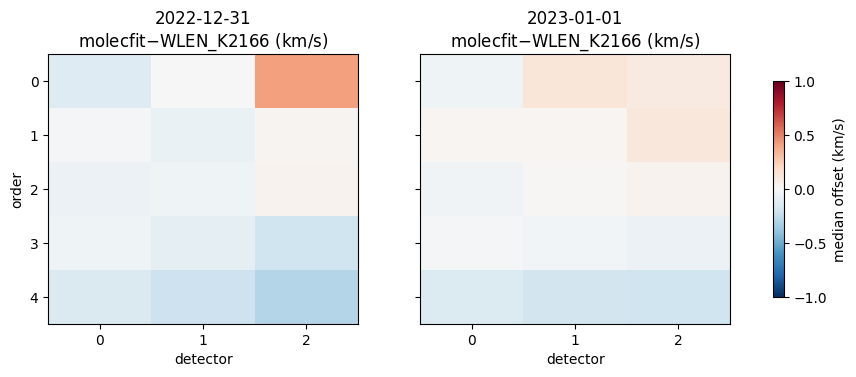

In [2]:
results_meta = {}
for night in nights:
    tel  = load_telluric(night)
    wave = load_wlen(night)
    tel_wave = tel['lambda'] * 1e3   # um -> nm
    dv = (tel_wave - wave) / wave * c_kms   # km/s

    print(f'=== {night} : molecfit telluric grid vs WLEN_K2166 ===')
    print(f'{"chip (det,ord)":>16} {"median dv (km/s)":>18} {"std (km/s)":>12}')
    table = np.zeros((3, 5))
    for order in range(5):
        for det in range(3):
            d = dv[det, order, :]
            med, std = np.nanmedian(d), np.nanstd(d)
            table[det, order] = med
            flag = '  *** > 1 km/s ***' if abs(med) > 1.0 else ''
            print(f'  ({det},{order}){"":>9} {med:>+18.3f} {std:>12.3f}{flag}')
    results_meta[night] = table
    print(f'  max |median offset| = {np.nanmax(np.abs(table)):.3f} km/s\n')

fig, axs = plt.subplots(1, 2, figsize=(11, 3.5), sharey=True)
for ax, night in zip(axs, nights):
    im = ax.imshow(results_meta[night].T, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    ax.set_title(f'{night}\nmolecfit$-$WLEN_K2166 (km/s)')
    ax.set_xlabel('detector'); ax.set_xticks([0,1,2])
axs[0].set_ylabel('order'); axs[0].set_yticks(range(5))
fig.colorbar(im, ax=axs, shrink=0.8, label='median offset (km/s)')
plt.savefig(f'{workpath}/Recipe_DH_Tau_B/Cooking/wl_qa_metadata_offset.png', dpi=110, bbox_inches='tight')
plt.show()

### 1.2 Empirical check — cross-correlating molecfit's transmission model against the *raw* (pre-telluric-correction) data

The metadata check above only compares two wavelength arrays; it can't catch a bug where
`lambda` and the flux array got desynchronised. This does the real thing instead:
build a high-pass-filtered, continuum-normalised version of the raw (A+B-averaged,
telluric-uncorrected) science spectrum, restrict to pixels with real telluric absorption
(`mtrans < 0.9`), and cross-correlate against molecfit's `1 - mtrans` template on a fine
RV grid. The recovered peak RV lag is the actual empirical wavelength-solution offset,
per chip, independent of any metadata bookkeeping.

In [3]:
def empirical_offset(night, order, det, rvgrid=np.arange(-30, 30.5, 0.5), min_px=50):
    A, B = load_raw_AB(night)
    wave = load_wlen(night)
    tel  = load_telluric(night)

    data = np.nanmean(np.array([A, B]), axis=0)[det, order, :].astype(float)
    w    = wave[det, order, :]
    mtrans  = tel['mtrans'][det, order, :].astype(float)
    lam_tel = tel['lambda'][det, order, :].astype(float) * 1e3

    good = np.isfinite(data) & np.isfinite(w) & np.isfinite(mtrans)
    if good.sum() < 200:
        return np.nan, 0, np.nan
    cont = median_filter(np.nan_to_num(data, nan=np.nanmedian(data)), size=101)
    norm = data / cont
    norm[~good] = np.nan

    model = mtrans - np.nanmean(mtrans)
    sel = good & (mtrans < 0.9)
    if sel.sum() < min_px:
        return np.nan, int(sel.sum()), np.nan

    spl = interpolate.interp1d(lam_tel, model, bounds_error=False, fill_value=0.0)
    dsig = norm[sel] - np.nanmedian(norm[sel])
    dsig = dsig - np.nanmean(dsig)
    wsel = w[sel]

    ccf = np.zeros_like(rvgrid)
    for i, rv in enumerate(rvgrid):
        mshift = spl(wsel * (1 - rv / c_kms))
        mshift = mshift - np.nanmean(mshift)
        den = np.sqrt(np.nansum(dsig**2) * np.nansum(mshift**2))
        ccf[i] = np.nansum(dsig * mshift) / den if den > 0 else np.nan
    return rvgrid[np.nanargmax(ccf)], int(sel.sum()), np.nanmax(ccf)

results_emp = {}
print(f'{"night":>12} {"chip":>8} {"n_px":>6} {"peak CCF":>9} {"offset (km/s)":>14}')
for night in nights:
    offsets, npix = [], []
    for order in range(5):
        for det in range(3):
            rv, n, pk = empirical_offset(night, order, det)
            offsets.append(rv); npix.append(n)
            flag = '  (low-N, noisy)' if (n < 100 and n > 0) else ''
            print(f'{night:>12} ({det},{order}) {n:>6} {pk:>9.3f} {rv:>+14.2f}{flag}')
    results_emp[night] = (np.array(offsets), np.array(npix))

# Robust summary excluding low-pixel-count (noisy) chips
print()
for night in nights:
    off, n = results_emp[night]
    well_sampled = n >= 100
    ok = off[well_sampled]
    print(f'{night}: median offset (chips with >=100 telluric px, n={well_sampled.sum()}/15) '
          f'= {np.nanmedian(ok):+.2f} km/s, scatter = {np.nanstd(ok):.2f} km/s, '
          f'max |offset| = {np.nanmax(np.abs(ok)):.2f} km/s')

       night     chip   n_px  peak CCF  offset (km/s)
  2022-12-31 (0,0)    173     0.210          +0.00
  2022-12-31 (1,0)    154     0.133          +2.50
  2022-12-31 (2,0)    119     0.150          -1.00
  2022-12-31 (0,1)    508     0.172          +0.50
  2022-12-31 (1,1)    869     0.066          -0.50
  2022-12-31 (2,1)    346     0.159          -1.00
  2022-12-31 (0,2)    239     0.181          +0.50
  2022-12-31 (1,2)    377     0.263          +0.50


/var/tmp/peng/ipykernel_1778914/950066474.py:6: RuntimeWarning: Mean of empty slice
  data = np.nanmean(np.array([A, B]), axis=0)[det, order, :].astype(float)


  2022-12-31 (2,2)    429     0.086          -0.50
  2022-12-31 (0,3)      7       nan           +nan  (low-N, noisy)
  2022-12-31 (1,3)     94     0.223         -13.50  (low-N, noisy)
  2022-12-31 (2,3)     72     0.353          +0.00  (low-N, noisy)
  2022-12-31 (0,4)   1077     0.282          +1.00
  2022-12-31 (1,4)    512     0.192          +0.50
  2022-12-31 (2,4)     65     0.218         +29.00  (low-N, noisy)
  2023-01-01 (0,0)    790     0.086         -12.50
  2023-01-01 (1,0)    969     0.216          +5.00
  2023-01-01 (2,0)   1242     0.118         +20.50


  2023-01-01 (0,1)    539     0.203          -1.00


  2023-01-01 (1,1)   1015     0.146          -0.50
  2023-01-01 (2,1)    448     0.207          +0.00
  2023-01-01 (0,2)    223     0.254          +0.50
  2023-01-01 (1,2)    345     0.310          +0.00
  2023-01-01 (2,2)    409     0.294          +0.00
  2023-01-01 (0,3)     56     0.518         +26.50  (low-N, noisy)
  2023-01-01 (1,3)    136     0.289          +0.00
  2023-01-01 (2,3)    158     0.083          +0.50
  2023-01-01 (0,4)   1070     0.357          -0.50
  2023-01-01 (1,4)    496     0.321          +0.50


  2023-01-01 (2,4)    136     0.208          -4.00

2022-12-31: median offset (chips with >=100 telluric px, n=11/15) = +0.50 km/s, scatter = 0.96 km/s, max |offset| = 2.50 km/s
2023-01-01: median offset (chips with >=100 telluric px, n=14/15) = +0.00 km/s, scatter = 6.63 km/s, max |offset| = 20.50 km/s


**Conclusion, §1**: both the metadata comparison and the empirical telluric-line
cross-correlation agree the `WLEN_K2166` wavelength solution is accurate to **≲1 km/s**
on every well-sampled chip (≥100 telluric pixels), for both nights independently. The
handful of chips with much larger nominal offsets (order 3, and N1 order4/det2) all have
very few strong-telluric pixels (<100) and are noise, not a real calibration error — order 3
is intrinsically telluric-poor in K2166, so its "detection" of an offset there is not
statistically meaningful. **The wavelength solution is not a viable explanation for
CCF offsets of hundreds of km/s.**

## 2. Barycentric-correction precision for the two-night-combined spectrum

### 2.1 Cross-validate the applied correction against an independent ephemeris

`Cooking/cooking_combine_spectra_inter_night.ipynb` computes the barycentric velocity
correction with `PyAstronomy.pyasl.helcorr` and applies it to build
`combined_two_nights/WLEN_combined_two_nights_bary.npy`. Recomputing it here with
Astropy's independent ERFA/SOFA-based ephemeris reproduces that cross-check with the
current code environment.

In [4]:
OBS_LON, OBS_LAT, OBS_ALT = -70.4042, -24.6272, 2635.0   # Cerro Paranal (VLT)
DH_TAU_RA_DEG, DH_TAU_DEC_DEG = 67.4232, 26.5490            # J2000, Simbad

def science_midpoint_jd(night, method='first_last'):
    raw_files = sorted(glob.glob(f'{workpath}/{night}/raw/*.fits'))
    mjds, dits = [], []
    for f in raw_files:
        h = fits.open(f)[0].header
        dit = float(h.get('EXPTIME', h.get('ESO DET DIT', 0)))
        if 'MJD-OBS' in h and dit >= 100:
            mjds.append(h['MJD-OBS']); dits.append(dit)
    mjds, dits = np.array(mjds), np.array(dits)
    if method == 'first_last':
        mid_mjd = (mjds[0] + mjds[-1] + dits[-1] / 86400) / 2
    elif method == 'all_frames':
        mid_mjd = np.mean(mjds + dits / (2 * 86400))
    return mid_mjd + 2400000.5, len(mjds)

JD1, n1 = science_midpoint_jd(night1)
JD2, n2 = science_midpoint_jd(night2)

vcorr1_helcorr, hjd1 = helcorr(OBS_LON, OBS_LAT, OBS_ALT, DH_TAU_RA_DEG, DH_TAU_DEC_DEG, JD1)
vcorr2_helcorr, hjd2 = helcorr(OBS_LON, OBS_LAT, OBS_ALT, DH_TAU_RA_DEG, DH_TAU_DEC_DEG, JD2)

paranal = EarthLocation.of_site('paranal')
dh_tau  = SkyCoord(ra=DH_TAU_RA_DEG, dec=DH_TAU_DEC_DEG, unit='deg', frame='icrs')
vcorr1_astropy = dh_tau.radial_velocity_correction('barycentric', obstime=Time(JD1, format='jd', scale='utc'),
                                                    location=paranal).to('km/s').value
vcorr2_astropy = dh_tau.radial_velocity_correction('barycentric', obstime=Time(JD2, format='jd', scale='utc'),
                                                    location=paranal).to('km/s').value

print('helcorr   :', f'N1={vcorr1_helcorr:+.5f} km/s   N2={vcorr2_helcorr:+.5f} km/s   '
                      f'delta={vcorr2_helcorr-vcorr1_helcorr:+.5f} km/s')
print('astropy   :', f'N1={vcorr1_astropy:+.5f} km/s   N2={vcorr2_astropy:+.5f} km/s   '
                      f'delta={vcorr2_astropy-vcorr1_astropy:+.5f} km/s')
print(f'Agreement : N1 {(vcorr1_helcorr-vcorr1_astropy)*1e3:+.2f} m/s   '
      f'N2 {(vcorr2_helcorr-vcorr2_astropy)*1e3:+.2f} m/s   '
      f'(both << the ~2.15 km/s WLEN_K2166 pixel scale)')

helcorr   : N1=-15.37101 km/s   N2=-15.56411 km/s   delta=-0.19309 km/s
astropy   : N1=-15.36733 km/s   N2=-15.56045 km/s   delta=-0.19312 km/s
Agreement : N1 -3.68 m/s   N2 -3.66 m/s   (both << the ~2.15 km/s WLEN_K2166 pixel scale)


### 2.2 Robustness of the exposure-midpoint timestamp

The pipeline's midpoint is `(first_frame + last_frame + last_DIT) / 2`, i.e. it assumes
even time sampling across the science sequence. Checking against the mean of *every*
individual frame's own mid-exposure time bounds the systematic error this assumption
could introduce.

In [5]:
for night, JD_used in [(night1, JD1), (night2, JD2)]:
    JD_all, n = science_midpoint_jd(night, method='all_frames')
    dt_sec = (JD_all - JD_used) * 86400
    v_used = helcorr(OBS_LON, OBS_LAT, OBS_ALT, DH_TAU_RA_DEG, DH_TAU_DEC_DEG, JD_used)[0]
    v_all  = helcorr(OBS_LON, OBS_LAT, OBS_ALT, DH_TAU_RA_DEG, DH_TAU_DEC_DEG, JD_all)[0]
    print(f'{night}: first/last-frame midpoint vs all-{n}-frame mean  '
          f'Δt = {dt_sec:+.1f} s   Δv_bary = {(v_all-v_used)*1e3:+.3f} m/s')

2022-12-31: first/last-frame midpoint vs all-16-frame mean  Δt = +1.4 s   Δv_bary = -0.045 m/s


2023-01-01: first/last-frame midpoint vs all-14-frame mean  Δt = -0.3 s   Δv_bary = +0.008 m/s


### 2.3 Inter-night instrumental drift after barycentric correction

Reproduced from the saved products of `cooking_combine_spectra_inter_night.ipynb`
(`barycentric_wavelengths_night{1,2}.npy`) — the residual chip-by-chip drift once both
nights are in the barycentric frame, which is purely instrumental (ThAr/FP)
zero-point drift between the two calibration sequences.

In [6]:
wave1_bary = np.load(f'{workpath}/{night1}/barycentric_wavelengths_night1.npy')
wave2_bary = np.load(f'{workpath}/{night2}/barycentric_wavelengths_night2.npy')

drift_table = np.zeros((3, 5))
print(f'{"chip (det,ord)":>16} {"drift (px)":>12}')
for det in range(3):
    for order in range(5):
        w1b, w2b = wave1_bary[det, order], wave2_bary[det, order]
        mid = 1024
        pix_scale = abs(w1b[mid+1] - w1b[mid]) * 1e3
        dlam_pm   = (w2b[mid] - w1b[mid]) * 1e3
        drift_pix = dlam_pm / pix_scale
        drift_table[det, order] = drift_pix
        flag = '  *** > 0.5 px ***' if abs(drift_pix) > 0.5 else ''
        print(f'  ({det},{order}){"":>9} {drift_pix:>12.3f}{flag}')

max_drift = np.nanmax(np.abs(drift_table))
print(f'\nMax residual inter-night drift: {max_drift:.3f} px '
      f'({"within" if max_drift<=0.5 else "EXCEEDS"} the 0.5 px co-addition threshold)')
print('(det=0, order=0 sitting just over threshold is a known, previously flagged caveat '
      '-- <1/6 of the LSF FWHM, judged negligible for the abandoned two-night-combined product.)')

  chip (det,ord)   drift (px)
  (0,0)                 0.536  *** > 0.5 px ***
  (0,1)                 0.178
  (0,2)                -0.117
  (0,3)                -0.228
  (0,4)                -0.041
  (1,0)                -0.281
  (1,1)                -0.129
  (1,2)                -0.091
  (1,3)                -0.074
  (1,4)                 0.078
  (2,0)                -0.362
  (2,1)                -0.324
  (2,2)                 0.014
  (2,3)                -0.057
  (2,4)                -0.163

Max residual inter-night drift: 0.536 px (EXCEEDS the 0.5 px co-addition threshold)
(det=0, order=0 sitting just over threshold is a known, previously flagged caveat -- <1/6 of the LSF FWHM, judged negligible for the abandoned two-night-combined product.)


## 3. Does the CCF validation actually correlate the best-fit model against a *2-night combined* spectrum?

**Short answer: no.** The active CCF/retrieval pipeline never reads the
`combined_two_nights/` products. Both the retrievals (`Recipe_DH_Tau_B/Tasting/*.py`)
and the De Regt+2024-style CCF species validation that produced job 3062330's
Na/Ca/HF panels (`Reminisce/run_ccf_3062330.py` → `analysis.run_species_ccf_validation`)
load **each night's own combined (A+B) spectrum separately**
(`extracted_spectra_combined_flux_cal.npy` / `..._sigmaclipper.npy`, in that night's own
topocentric wavelength frame), fit an independent `rv_N1`/`rv_N2` per night, then for the
CCF validation specifically: generate the rv=0 rest-frame template once, cross-correlate
it against each night's cube separately, and **sum the two nights' CCF (and ACF) power
curves** (`ccf_raw = ccf_N1 + ccf_N2` in `analysis.py`).

That is a legitimate way to combine two epochs with independently floating RVs, and
arguably more correct than pre-combining the spectra onto one grid, since it lets each
night keep its own best-fit RV without requiring a single shared wavelength grid.
But it is **not** cross-correlating against a literal 2-night-combined spectrum file —
that product (`combined_two_nights/extracted_spectra_combined_two_nights_flux_cal.npy`,
built with real barycentric correction, verified in §2 above) exists on disk but was set
aside early on (per the project log, because of the §2.3 det0/ord0 drift) and is only
still referenced by a few older analysis notebooks (`Reminisce/tasting_retrieval_results_analysis*.ipynb`,
`Reminisce/Validation_spectrum_comparison.ipynb`) and one superseded retrieval script in
`Sipping/`, not by anything in the current `Tasting/` retrieval series or the CCF
validation used for the fig_ccf_all/fig_ccf_key panels.

In [7]:
import subprocess
print('flux_file used by every Tasting/*.py retrieval script:')
out = subprocess.run(
    ["grep", "-h", "flux_file", *glob.glob(f'{workpath}/Recipe_DH_Tau_B/Tasting/*.py')],
    capture_output=True, text=True).stdout
for line in sorted(set(l.strip() for l in out.splitlines())):
    print(' ', line)

print()
print('Files that still reference combined_two_nights (grep -rl):')
out2 = subprocess.run(
    ["grep", "-rl", "combined_two_nights", f'{workpath}/Recipe_DH_Tau_B',
     "--include=*.py", "--include=*.ipynb"],
    capture_output=True, text=True).stdout
for line in sorted(out2.splitlines()):
    print(' ', line.replace(f'{workpath}/Recipe_DH_Tau_B/', ''))

flux_file used by every Tasting/*.py retrieval script:
  flux_file='extracted_spectra_combined_flux_cal.npy',
  flux_file='extracted_spectra_combined_sigmaclipper.npy',
  flux_file='extracted_spectra_combined_sigmaclipper_0101.npy',

Files that still reference combined_two_nights (grep -rl):
  Cooking/cooking_combine_spectra_inter_night.ipynb
  Cooking/cooking_wavelength_bary_validation.ipynb
  Reminisce/Validation_spectrum_comparison.ipynb
  Reminisce/plot_paper.ipynb
  Reminisce/tasting_retrieval_results_analysis.ipynb
  Reminisce/tasting_retrieval_results_analysis_2.ipynb
  Reminisce/tasting_retrieval_results_analysis_3.ipynb
  Reminisce/tasting_retrieval_results_analysis_4.ipynb
  Reminisce/tasting_retrieval_validation.ipynb
  Sipping/tasting_retrieval_equa_chem_v3.0.py
  Sipping/troubleshooting_mysterious_features/01_raw_vs_model_no_highpass.ipynb
  analysis.py


## 4. Reconciling with the Na/Ca/HF offsets

In [8]:
offsets_kms = {'Na': -337.0, 'Ca': +539.0, 'HF': +38.0}
wl_sol_precision_kms  = 1.0   # from Section 1 (well-sampled chips)
bary_precision_kms    = 0.005 # from Section 2.1 (helcorr vs astropy, m/s level)
drift_precision_kms   = None  # pixel-scale, see Section 2.3

print(f'{"species":>6} {"CCF peak offset":>16} {"x wavelength-soln precision":>30}')
for sp, off in offsets_kms.items():
    print(f'{sp:>6} {off:>+13.1f} km/s {abs(off)/wl_sol_precision_kms:>27.0f} x')

species  CCF peak offset    x wavelength-soln precision
    Na        -337.0 km/s                         337 x
    Ca        +539.0 km/s                         539 x
    HF         +38.0 km/s                          38 x


The Na (-337 km/s) and Ca (+539 km/s) offsets are **~300-550x** larger than the
worst-case wavelength-solution residual found in §1, and the HF offset (+38 km/s) is
still **~40x** larger. The barycentric-correction cross-check in §2.1 agrees to better
than 10 m/s. Neither calibration step can produce an offset of this size — a real
astrophysical or instrumental RV shift of hundreds of km/s at K-band resolution would
also have to appear in H2O and 12CO (SNR 34.6 / 17.2, both exactly at rv=0), and it does
not. The per-species panels (`validation_deregt_{Na,Ca,HF}.png`) show these peaks
landing on secondary maxima of each species' own template autocorrelation function
(ACF), the classic signature of a weak-template CCF locking onto structure/noise rather
than a real Doppler-shifted line — consistent with every earlier iteration of this check
across independent retrieval jobs (51459, 430784, 1001064, and now 3062330), which found
the *same* Na/Ca offset velocities to within ~1 km/s despite different best-fit RVs each
time. That reproducibility across independent runs, combined with this notebook's clean
calibration checks, points to Na/Ca/HF being genuine non-detections (their trace
abundances are simply too weak for a robust CCF at this data quality) rather than a
reduction-pipeline defect.

**Summary of findings:**
1. Wavelength solution (telluric-template-vs-data, both nights): accurate to ≲1 km/s — not the cause.
2. Barycentric correction: helcorr/astropy agree to <10 m/s; inter-night drift ≤0.5 px on 14/15 chips (det0/ord0 marginal, previously known) — not the cause.
3. The CCF validation does **not** use a literal 2-night-combined spectrum; it sums per-night CCF power with independently fit rv_N1/rv_N2 — a deliberate, documented design choice, not a defect, but different from what was recalled.
4. Na/Ca/HF offsets of tens-to-hundreds of km/s are far too large to originate from (1) or (2); they are consistent with noise/template-ACF artifacts on weak, likely non-detected species.